<a href="https://colab.research.google.com/github/sechan-design/2026-data-science-and-machine-learning/blob/main/%EC%9C%A4%EC%84%B8%EC%B0%AC_%ED%86%B5%EA%B3%84%EC%A0%81_%EC%B6%94%EC%A0%95(%EC%A0%9C%EC%A3%BC%ED%8F%89%EA%B7%A0%EA%B8%B0%EC%98%A8).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 한글 폰트 설정을 위한 라이브러리 설치
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 38.6 MB/s eta 0:00:00


# Ⅱ-2-1 통계적 추정
### [기본 활동]히스토그램과 정규 분포 그래프로 시각화하기



**[설명]**

1.   아래와 같이 파일 선택 버튼이 보이면 컴퓨터에 저장된 csv 파일을 찾아 업로드할 수있다.
2.   먼저 자신의 컴퓨터에 데이터세트(Ⅱ211_temperature_data_01.csv)가 다운로드되어 있어야 한다.




---


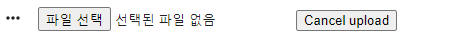

---

**[소스 코드]**

##(활동1) 데이터를 히스토그램으로 표현하기

1. 코드를 실행하고 '파일 선택'을 눌러 컴퓨터에 저장된 CSV 예제 파일을 업로드한다.

In [ ]:
from google.colab import files #코랩에서 파일 패키지 임포트하기
uploaded = files.upload() #컴퓨터에 저장된 파일 경로 지정하여 업로드하기
csv_file = '2025제주평균기온.csv'

Saving 2025제주평균기온.csv to 2025제주평균기온.csv


2. 제주특별자치도 평균 기온 데이터세트를 CSV로 불러온 다음 판다스 라이브러리를 이용하여 출력한다.

In [ ]:
import pandas as pd # 판다스 라이브러리 불러오기
import matplotlib.pyplot as plt # 맷플롯립 라이브러리 불러오기
df = pd.read_csv(csv_file, encoding ='cp949') # 한글 인코딩
df


,일자,평균기온
0,2025-01-01,7.6
1,2025-01-02,8.5
2,2025-01-03,6.0
3,2025-01-04,6.1
4,2025-01-05,8.1
...,...,...
360,2025-12-27,4.0
361,2025-12-28,8.3
362,2025-12-29,12.4
363,2025-12-30,8.8


In [ ]:
from numpy import datetime64

df['일자'] = df['일자'].astype('datetime64[ns]')

# 3월 데이터 추출
march_data = df[df['일자'].dt.month == 3]
march_data.reset_index(inplace=True,drop=True)
march_data

,일자,평균기온
0,2025-03-01,14.1
1,2025-03-02,16.1
2,2025-03-03,10.4
3,2025-03-04,8.1
4,2025-03-05,8.0
5,2025-03-06,7.8
6,2025-03-07,8.0
7,2025-03-08,9.1
8,2025-03-09,9.2
9,2025-03-10,9.9


3. 제주특별자치도 데이터세트에서 평균 기온 시리즈만 출력한다.

In [ ]:
print(march_data['평균기온'])

0     14.1
1     16.1
2     10.4
3      8.1
4      8.0
5      7.8
6      8.0
7      9.1
8      9.2
9      9.9
10    12.0
11    11.8
12    12.2
13    13.8
14     9.7
15     7.2
16     5.3
17     5.2
18     5.5
19     9.6
20    14.1
21    16.2
22    16.7
23    17.2
24    17.9
25    16.0
26    16.5
27     8.9
28     7.6
29     6.4
30     8.3
Name: 평균기온, dtype: float64


4. hist() 함수를 이용하여 x축에는 평균 기온, y축에는 데이터의 빈도수를 나타내는 히스토그램을 출력한다.

(array([4., 2., 6., 5., 1., 3., 1., 2., 4., 3.]),
 array([ 5.2 ,  6.47,  7.74,  9.01, 10.28, 11.55, 12.82, 14.09, 15.36,
        16.63, 17.9 ]),
 <BarContainer object of 10 artists>)

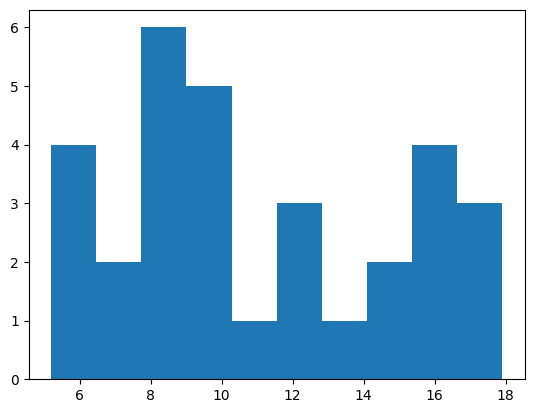

In [ ]:
#히스토그램 출력하기
plt.hist(march_data['평균기온'])

5. 제주특별자치도 평균 기온 데이터세트에서 평균 기온의 평균을 구한다.

In [ ]:
#3월 평균기온 column의 평균 구하기
march_data['평균기온'].mean()

np.float64(10.929032258064515)

##(활동2) 데이터를 정규 분포 그래프와 비교하여 통계적 추정하기

1. 코드를 실행하고 '파일 선택'을 눌러 컴퓨터에 저장된 CSV 예제 파일을 업로드한다.

In [ ]:
from google.colab import files
uploaded = files.upload() #컴퓨터에 저장된 파일 경로 지정하여 업로드하기
my_data_file = '2025제주평균기온.csv'

Saving 2025제주평균기온.csv to 2025제주평균기온 (2).csv


2. 업로드한 제주특별자치도 평균 기온 데이터세트를 읽어와 시본(seaborn)과 사이파이(scipy) 라이브러리를 이용하여 정규 분포 그래프를 출력하는 코드를 작성한다.

In [ ]:
import pandas as pd #판다스
from scipy import stats #사이파이
import seaborn as sns #시본
import numpy as np
import koreanize_matplotlib
csv_file='2025제주평균기온.csv'
df=pd.read_csv(csv_file, encoding='cp949')

In [ ]:
from numpy import datetime64

df['일자'] = df['일자'].astype('datetime64[ns]')

# 3월 데이터 추출
march_data = df[df['일자'].dt.month == 3]
march_data.reset_index(inplace=True,drop=True)
march_data

,일자,평균기온
0,2025-03-01,14.1
1,2025-03-02,16.1
2,2025-03-03,10.4
3,2025-03-04,8.1
4,2025-03-05,8.0
5,2025-03-06,7.8
6,2025-03-07,8.0
7,2025-03-08,9.1
8,2025-03-09,9.2
9,2025-03-10,9.9


/tmp/ipykernel_18085/913581816.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(march_data['평균기온'],fit=stats.norm)


<Axes: xlabel='평균기온', ylabel='Density'>

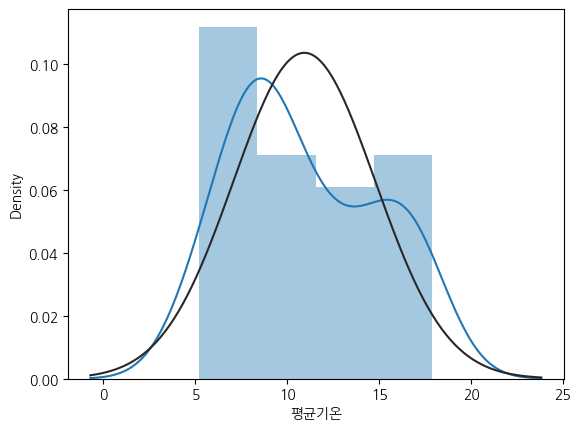

In [ ]:
#사이파이의 stats 서브패키지에 있는 norm 클래스가 정규분포 클래스다.
sns.distplot(march_data['평균기온'],fit=stats.norm)

10.929032258064515
3.855385303399531


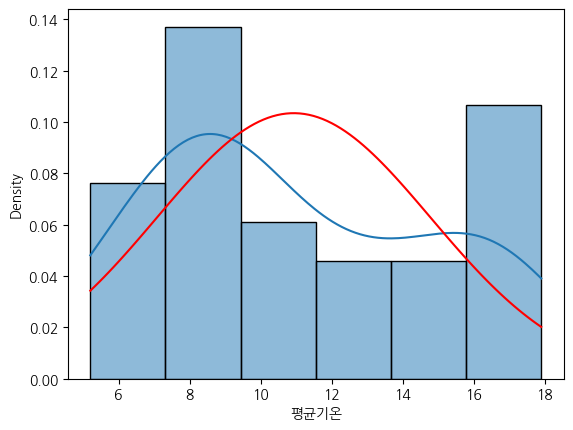

In [ ]:
import matplotlib.pyplot as plt
# [1단계] 히스토그램 출력
sns.histplot(march_data['평균기온'],kde=True , stat='density')

# [2단계] 정규분포 계산
mu,std = stats.norm.fit(march_data['평균기온'])
print(mu)
print(std)
# [3단계] 정규분포 그래프 출력

x = np.linspace(march_data['평균기온'].min(),march_data['평균기온'].max(),100)
p = stats.norm.pdf(x, mu ,std)
plt.plot(x,p,'red')